# Homework 3 Problems and Exercises

## 0. Setup

**Before starting, ensure you have installed dependencies:**
```
uv sync
```
Then select the `.venv` kernel in Jupyter before running any cells.

In [1]:
from penngrader.grader import *
import polars as pl
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.neighbors import NearestNeighbors
from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, f1_score, mean_squared_error, r2_score
from sklearn.pipeline import Pipeline

#PLEASE ENSURE YOUR PENN-ID IS ENTERED CORRECTLY. IF NOT, THE AUTOGRADER WON'T KNOW WHO
#TO ASSIGN POINTS TO YOU IN OUR BACKEND
STUDENT_ID = 79596034  # YOUR PENN-ID GOES HERE AS AN INTEGER

SECRET = STUDENT_ID

HW_ID = 'cis2450_spr26_HW3'

In [2]:
%%writefile notebook-config.yaml

grader_api_url: "https://yj0vsrf8l4.execute-api.us-east-1.amazonaws.com/Initial/TestSandbox"
grader_api_key: "dBB5ucuV5L6GyKFKmlrfP4bKkhtnA0bP42lR3rSh"
token_generator_url: "https://yj0vsrf8l4.execute-api.us-east-1.amazonaws.com/Initial/GetTokens"
token_generator_api_key: "dBB5ucuV5L6GyKFKmlrfP4bKkhtnA0bP42lR3rSh"

Overwriting notebook-config.yaml


In [3]:
if not isinstance(STUDENT_ID, int):
    raise ValueError('STUDENT_ID must be an integer representing your Penn ID.')
if len(str(STUDENT_ID)) != 8:
    raise ValueError('STUDENT_ID must be an 8-digit integer representing your Penn ID.')
if STUDENT_ID != SECRET:
    raise ValueError('SECRET does not match STUDENT_ID. Please ensure they are the same.')

grader = PennGrader('notebook-config.yaml', HW_ID, STUDENT_ID, SECRET, 'cis2450_spr26')

PennGrader initialized with Student ID: 79596034

Make sure this correct or we will not be able to store your grade


# Part 0: EDA & PCA

In this section you will load and clean the music dataset, perform exploratory data analysis,
label songs by popularity tier, and apply PCA to visualize the audio feature space.

## 0.1 Load and Clean Data [5 Points]

Implement `load_and_clean_data` in `transformations/transformations_stub.py` and then copy it here.

The dataset (`data/data.csv`) contains ~170k songs with audio features spanning 1921–2020.
Many songs have a popularity of 0–2, which likely indicates missing or unreliable data rather
than genuinely unpopular songs. We remove them before modeling.

**Your function should:**
- Read the CSV file at `filepath` using Polars
- Remove rows where `popularity <= 2`
- Return the cleaned DataFrame with all original columns

In [4]:
# Run this cell to download the dataset if needed
from data.data_loader import get_spotify_dataset_path

dataset_path = get_spotify_dataset_path()

In [5]:
import polars as pl
# TODO: Copy load_and_clean_data from transformations/transformations_stub.py.
def load_and_clean_data(filepath: str) -> pl.DataFrame:
    """
    Load the music dataset and perform initial cleaning.

    Requirements:
    - Read the CSV file at filepath using Polars
    - Remove rows where popularity is 0, 1, or 2 (drop rows with popularity <= 2)
    - Return the cleaned DataFrame with all original columns

    Args:
        filepath: Path to the CSV file

    Returns:
        Cleaned Polars DataFrame

    Example:
        >>> df = load_and_clean_data('data/data.csv')
        >>> assert (df['popularity'] > 2).all()
    """
    return pl.read_csv(filepath).filter(pl.col("popularity") > 2)

df = load_and_clean_data(dataset_path)
assert (df['popularity'] > 2).all()
print(df.shape)


(138152, 19)


In [40]:
grader.grade('test_load_and_clean_data', load_and_clean_data)

Correct! You earned 5/5 points. You are a star!

Your submission has been successfully recorded in the gradebook.


## 0.2 Exploratory Data Analysis [2 Points]

Run the cells below to explore the dataset. Use these observations to inform your modeling choices.

In [6]:
# Load data and define the audio feature columns used throughout this notebook
df = load_and_clean_data(dataset_path)

AUDIO_FEATURES = [
    'acousticness', 'danceability', 'energy', 'instrumentalness',
    'liveness', 'loudness', 'speechiness', 'tempo', 'valence'
]

# Extract feature matrix for use throughout the notebook
X = df.select(AUDIO_FEATURES).to_numpy()

print(f'Dataset shape: {df.shape}')
print(f'Popularity range: {df["popularity"].min()} – {df["popularity"].max()}')
print(f'Feature matrix shape: {X.shape}')
df.describe()

# Standardize features for distance-based methods (KMeans, kNN)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
print(f'X_scaled mean (should be ~0): {X_scaled.mean(axis=0).round(2)}')

Dataset shape: (138152, 19)
Popularity range: 3 – 100
Feature matrix shape: (138152, 9)
X_scaled mean (should be ~0): [ 0. -0.  0. -0.  0.  0. -0.  0.  0.]


In [7]:
df.head()

valence,year,acousticness,artists,danceability,duration_ms,energy,explicit,id,instrumentalness,key,liveness,loudness,mode,name,popularity,release_date,speechiness,tempo
f64,i64,f64,str,f64,i64,f64,i64,str,f64,i64,f64,f64,i64,str,i64,str,f64,f64
0.0594,1921,0.982,"""['Sergei Rachmaninoff', 'James…",0.279,831667,0.211,0,"""4BJqT0PrAfrxzMOxytFOIz""",0.878,10,0.665,-20.096,1,"""Piano Concerto No. 3 in D Mino…",4,"""1921""",0.0366,80.954
0.963,1921,0.732,"""['Dennis Day']""",0.819,180533,0.341,0,"""7xPhfUan2yNtyFG0cUWkt8""",0.0,7,0.16,-12.441,1,"""Clancy Lowered the Boom""",5,"""1921""",0.415,60.936
0.0394,1921,0.961,"""['KHP Kridhamardawa Karaton Ng…",0.328,500062,0.166,0,"""1o6I8BglA6ylDMrIELygv1""",0.913,3,0.101,-14.85,1,"""Gati Bali""",5,"""1921""",0.0339,110.339
0.165,1921,0.967,"""['Frank Parker']""",0.275,210000,0.309,0,"""3ftBPsC5vPBKxYSee08FDH""",0.0000277,5,0.381,-9.316,1,"""Danny Boy""",3,"""1921""",0.0354,100.109
0.196,1921,0.579,"""['KHP Kridhamardawa Karaton Ng…",0.697,395076,0.346,0,"""4pyw9DVHGStUre4J6hPngr""",0.168,2,0.13,-12.506,1,"""Gati Mardika""",6,"""1921""",0.07,119.824


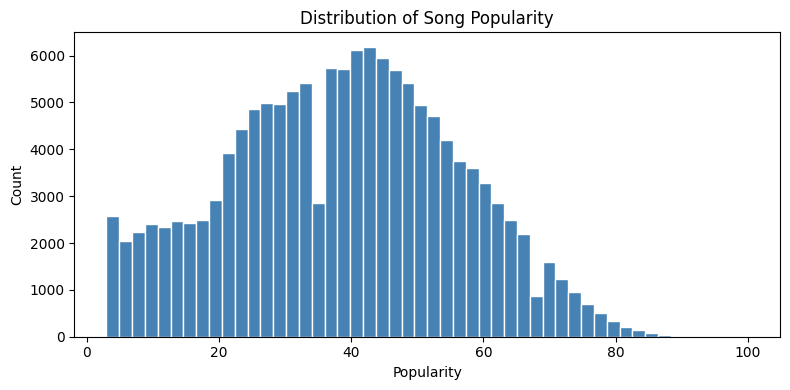

In [43]:
# Popularity distribution
plt.figure(figsize=(8, 4))
plt.hist(df['popularity'].to_list(), bins=50, color='steelblue', edgecolor='white')
plt.xlabel('Popularity')
plt.ylabel('Count')
plt.title('Distribution of Song Popularity')
plt.tight_layout()
plt.show()

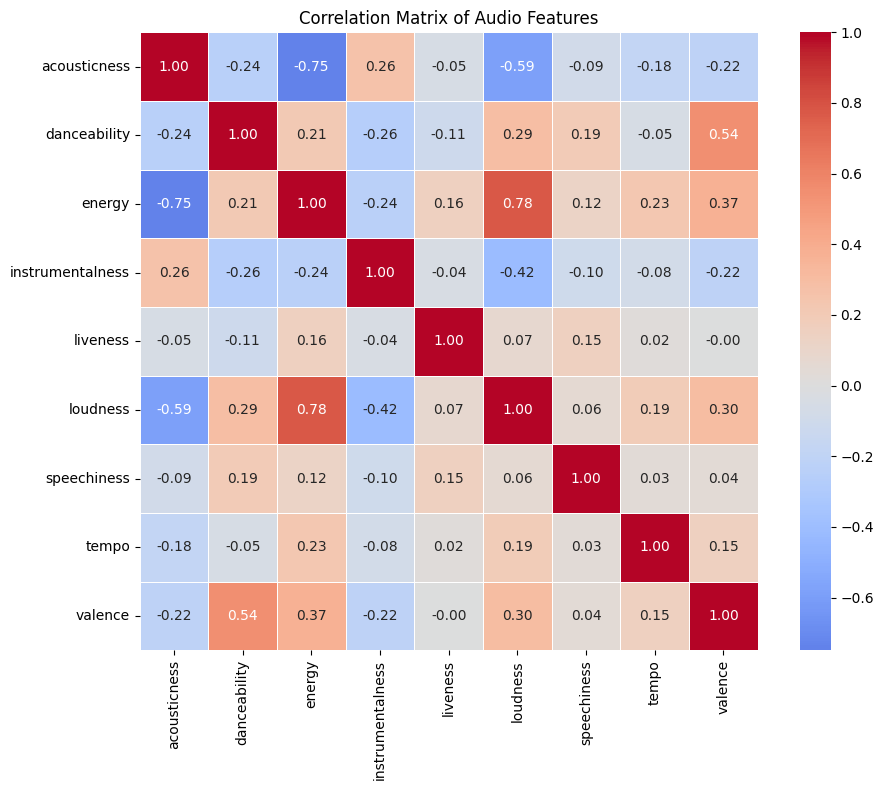

In [44]:
# Correlation heatmap of audio features
corr = df.select(AUDIO_FEATURES).to_pandas().corr()
plt.figure(figsize=(10, 8))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0,
            square=True, linewidths=0.5)
plt.title('Correlation Matrix of Audio Features')
plt.tight_layout()
plt.show()

**Short Answer [2 Points]:** Looking at the distributions and correlations above:
- Which audio features appear most correlated with each other?
- Are there any features whose distributions look unusual or highly skewed?

*Energy and loudness appear the most correlated with each other (0.78). This makes sense because it seems natural for "louder" songs to have more energy associated with them. On the other hand, accousticness and energy are highly negatively correlated (-0.75). This also makes sense more accoustical instruments probably have less energy associated with them.*

*The distribution of song popularity looks rather skewed to me. It seems as though the vast majority of song popularities are really low but there are a few songs that have high popularities. This is probably a result of there only being a few popular artists compared to numerous small "indie" artists currently in the music market.*

## 0.3 Label Popularity Buckets [4 Points]

Implement `label_popularity_buckets` in `transformations/transformations_stub.py` and then copy it here.

**Your function should:**
- Add a `'popularity_bucket'` column with values `'low'` (popularity < 34),
  `'medium'` (34 ≤ popularity < 67), or `'high'` (popularity ≥ 67)
- Leave all existing columns unchanged

**Hint:** Use `pl.when(...).then(...).otherwise(...)` for conditional column creation.

In [45]:
def label_popularity_buckets(df: pl.DataFrame) -> pl.DataFrame:
    """
    Add a 'popularity_bucket' column categorizing songs by popularity.

    Requirements:
    - Add a new column 'popularity_bucket' with string values:
        - 'low'    if popularity < 34
        - 'medium' if 34 <= popularity < 67
        - 'high'   if popularity >= 67
    - Do not modify any existing columns
    - Return the DataFrame with the new column appended

    Args:
        df: Polars DataFrame with a 'popularity' column (integer)

    Returns:
        DataFrame with added 'popularity_bucket' column

    Example:
        >>> sample = pl.DataFrame({'popularity': [10, 50, 80]})
        >>> result = label_popularity_buckets(sample)
        >>> result['popularity_bucket'].to_list()
        ['low', 'medium', 'high']
    """
    return df.with_columns(
        pl.when(pl.col("popularity") < 34)
        .then(pl.lit("low"))
        .when(pl.col("popularity") < 67)
        .then(pl.lit("medium"))
        .otherwise(pl.lit("high"))
        .alias("popularity_bucket")
    )

# Example test:
sample = pl.DataFrame({'popularity': [10, 50, 80]})
label_popularity_buckets(sample)['popularity_bucket'].to_list()
# Expected: ['low', 'medium', 'high']


['low', 'medium', 'high']

In [46]:
grader.grade('test_label_popularity_buckets', label_popularity_buckets)

Correct! You earned 4/4 points. You are a star!

Your submission has been successfully recorded in the gradebook.


## 0.4 PCA [8 Points]

Implement `run_pca` in `transformations/transformations_stub.py` and then copy it here.

PCA (Principal Component Analysis) reduces high-dimensional feature spaces into a smaller
number of components that capture most of the variance. Before applying PCA it is essential
to **standardize** features (zero mean, unit variance) so that features measured on different
scales (e.g., `loudness` in dB vs. `danceability` in [0,1]) contribute equally.

**Your function should:**
- Standardize `X` using `StandardScaler`
- Apply `PCA(n_components=n_components)`
- Return `(X_pca, explained_variance_ratio)` as a tuple of numpy arrays

**Hints:**
- `scaler.fit_transform(X)` standardizes in one step
- After fitting, access `pca.explained_variance_ratio_` for the ratio array

In [ ]:
def run_pca(X: np.ndarray, n_components: int = 2) -> tuple:
    """
    Standardize features and apply PCA for dimensionality reduction.

    Requirements:
    - Standardize X using StandardScaler (zero mean, unit variance)
    - Apply PCA with the specified number of components
    - Return a tuple: (X_pca, explained_variance_ratio)
        - X_pca: numpy array of shape (n_samples, n_components)
        - explained_variance_ratio: numpy array of length n_components

    Args:
        X: numpy array of shape (n_samples, n_features)
        n_components: number of principal components to keep (default 2)

    Returns:
        Tuple of (X_pca, explained_variance_ratio)

    Example:
        >>> X = np.random.random((100, 9))
        >>> X_pca, evr = run_pca(X, n_components=2)
        >>> X_pca.shape
        (100, 2)
        >>> len(evr)
        2
    """
    X_scaled = StandardScaler().fit_transform(X)
    pca = PCA(n_components=n_components)
    X_pca = pca.fit_transform(X_scaled)
    return X_pca, pca.explained_variance_ratio_

# Example test:
X_test = np.random.random((100, 9))
X_pca, evr = run_pca(X_test, n_components=2)
assert X_pca.shape == (100, 2)
assert len(evr) == 2

In [48]:
grader.grade('test_run_pca', run_pca)

Correct! You earned 6/6 points. You are a star!

Your submission has been successfully recorded in the gradebook.


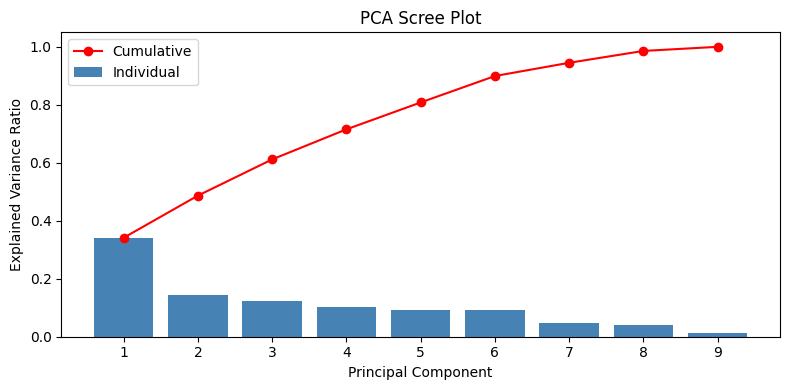

Cumulative variance explained by first 2 PCs: 0.487


In [49]:
# Scree plot: how much variance does each component explain?
_, explained_var_all = run_pca(X, n_components=len(AUDIO_FEATURES))

plt.figure(figsize=(8, 4))
components = range(1, len(explained_var_all) + 1)
plt.bar(components, explained_var_all, color='steelblue', label='Individual')
plt.plot(components, np.cumsum(explained_var_all), 'ro-', label='Cumulative')
plt.xlabel('Principal Component')
plt.ylabel('Explained Variance Ratio')
plt.title('PCA Scree Plot')
plt.xticks(components)
plt.legend()
plt.tight_layout()
plt.show()
print('Cumulative variance explained by first 2 PCs:',
      round(float(sum(explained_var_all[:2])), 3))

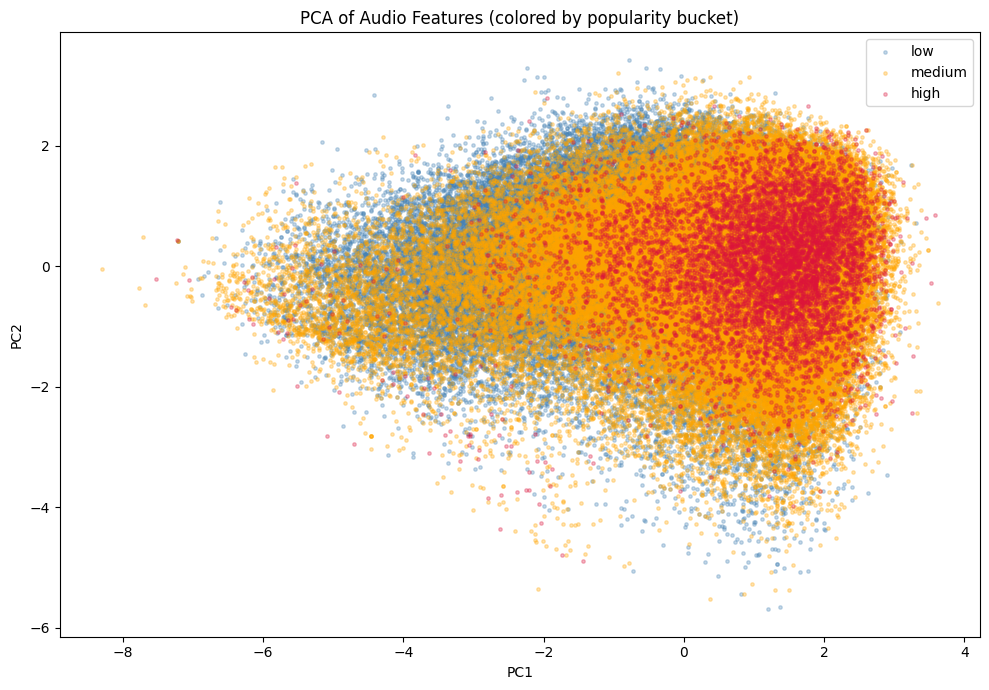

In [50]:
# 2D scatter plot of PC1 vs PC2, colored by popularity bucket
X_pca_2d, _ = run_pca(X, n_components=2)
df_bucketed = label_popularity_buckets(df)
bucket_labels = df_bucketed['popularity_bucket'].to_list()

color_map = {'low': 'steelblue', 'medium': 'orange', 'high': 'crimson'}
plt.figure(figsize=(10, 7))
for bucket, color in color_map.items():
    idx = [i for i, b in enumerate(bucket_labels) if b == bucket]
    plt.scatter(X_pca_2d[idx, 0], X_pca_2d[idx, 1],
                c=color, label=bucket, alpha=0.3, s=6)
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.title('PCA of Audio Features (colored by popularity bucket)')
plt.legend()
plt.tight_layout()
plt.show()

**Short Answer [2 Points]:**
- What patterns (if any) appear when you color the PCA scatter by popularity bucket?
- What information might PCA be discarding by projecting 9 features onto 2 components?

*When we color the PCA scatter by popularity bucket, I notice that the more popular music artists have higher values for PC1. This could indicate that PC1 is capturing some sort of metric associated with popularity.*

*By projecting 9 features onto 2 components, the PCA will be discarding about 50% of the explained variance. While we don't know exactly what type of information the PCA will discard, the interpretability of original features (ex. loudness, energy), might be diminished. Rare or outlier patterns may be supressed into discarded componenets as well*

# Part 1: K-Means & kNN for Music Recommendation

In this section you will use unsupervised clustering and nearest-neighbor search
to discover structure in the audio feature space and build a simple song recommender.

## 1.1 Elbow Method [5 Points]

Implement `find_elbow_inertias` in `transformations/transformations_stub.py` and then copy it here.

The **elbow method** helps choose *k* by plotting inertia (within-cluster sum of squares)
for a range of k values. The "elbow" — where adding more clusters yields diminishing returns —
suggests a good k.

**Your function should:**
- For each `k` in `k_range`, fit `KMeans(n_clusters=k, random_state=42)`
- Collect `model.inertia_` after each fit
- Return the list of inertia values in the same order as `k_range`

**Note:** Pass standardized features (`X_scaled`) to avoid scale-dominated distances.

In [ ]:
# TODO: Copy find_elbow_inertias from transformations/transformations_stub.py.
def find_elbow_inertias(X: np.ndarray, k_range: list) -> list:
    """
    Run KMeans for each k in k_range and collect inertia values for the elbow method.

    Requirements:
    - For each k in k_range, fit a KMeans model with random_state=42
    - Collect the inertia (sum of squared distances to nearest cluster center)
    - Return a list of inertia values in the same order as k_range

    Args:
        X: numpy array of shape (n_samples, n_features)
        k_range: list of integers (number of clusters to try)

    Returns:
        List of float inertia values, one per k in k_range

    Example:
        >>> inertias = find_elbow_inertias(X, k_range=[2, 3, 4, 5])
        >>> len(inertias)
        4
        >>> inertias[0] > inertias[-1]  # Inertia decreases as k increases
        True
    """
    return [
        KMeans(n_clusters=k, random_state=42).fit(X).inertia_
        for k in k_range
    ]

# Example test:
inertias = find_elbow_inertias(X, k_range=[2, 3, 4])
assert len(inertias) == 3
assert inertias[0] > inertias[-1]  # decreasing

In [52]:
grader.grade('test_find_elbow_inertias', find_elbow_inertias)

Correct! You earned 5/5 points. You are a star!

Your submission has been successfully recorded in the gradebook.


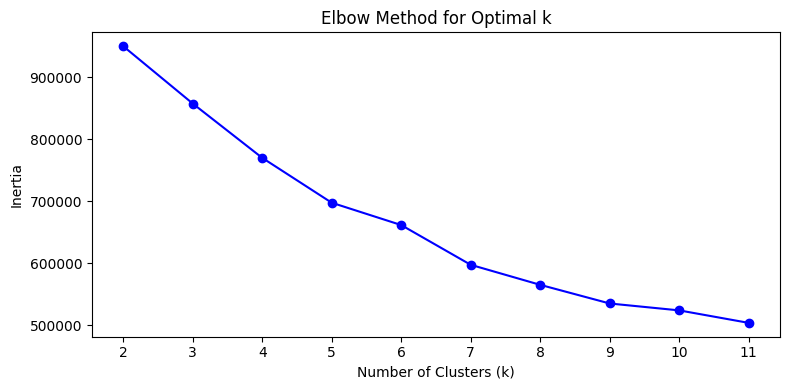

In [53]:
# Run elbow method and plot — use the scree plot to choose OPTIMAL_K below
k_range = list(range(2, 12))
inertias = find_elbow_inertias(X_scaled, k_range)

plt.figure(figsize=(8, 4))
plt.plot(k_range, inertias, 'bo-')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Inertia')
plt.title('Elbow Method for Optimal k')
plt.xticks(k_range)
plt.tight_layout()
plt.show()

## 1.2 K-Means Clustering [7 Points]

Implement `run_kmeans` in `transformations/transformations_stub.py` and then copy it here.

**Your function should:**
- Fit `KMeans(n_clusters=k, random_state=random_state)`
- Return `(labels, inertia)` where `labels` is the array of cluster assignments
  and `inertia` is the model's inertia value

**Note:** This function receives already-standardized `X_scaled`; no internal scaling needed.

In [54]:
def run_kmeans(X: np.ndarray, k: int, random_state: int = 42) -> tuple:
    """
    Fit KMeans clustering and return cluster assignments and inertia.

    Requirements:
    - Fit KMeans with n_clusters=k and the given random_state
    - Return a tuple: (labels, inertia)
        - labels: numpy array of shape (n_samples,) with cluster assignments (integers)
        - inertia: float, sum of squared distances to nearest cluster center

    Args:
        X: numpy array of shape (n_samples, n_features)
        k: number of clusters
        random_state: random seed for reproducibility (default 42)

    Returns:
        Tuple of (labels, inertia)

    Example:
        >>> labels, inertia = run_kmeans(X, k=5)
        >>> len(np.unique(labels))
        5
        >>> inertia > 0
        True
    """
    kmeans = KMeans(n_clusters=k, random_state=random_state).fit(X)
    return kmeans.labels_, kmeans.inertia_

# Example test:
labels, inertia = run_kmeans(X, k=5)
assert len(np.unique(labels)) == 5
assert inertia > 0

In [55]:
grader.grade('test_run_kmeans', run_kmeans)

Correct! You earned 5/5 points. You are a star!

Your submission has been successfully recorded in the gradebook.


In [56]:
# Update OPTIMAL_K based on your elbow plot above
OPTIMAL_K = 7

cluster_labels, kmeans_inertia = run_kmeans(X_scaled, k=OPTIMAL_K)
print(f'KMeans inertia (k={OPTIMAL_K}): {kmeans_inertia:.2f}')
unique, counts = np.unique(cluster_labels, return_counts=True)
print('Cluster distribution:', dict(zip(unique.tolist(), counts.tolist())))

KMeans inertia (k=7): 597602.17
Cluster distribution: {0: 18239, 1: 24410, 2: 12680, 3: 8413, 4: 31725, 5: 36392, 6: 6293}


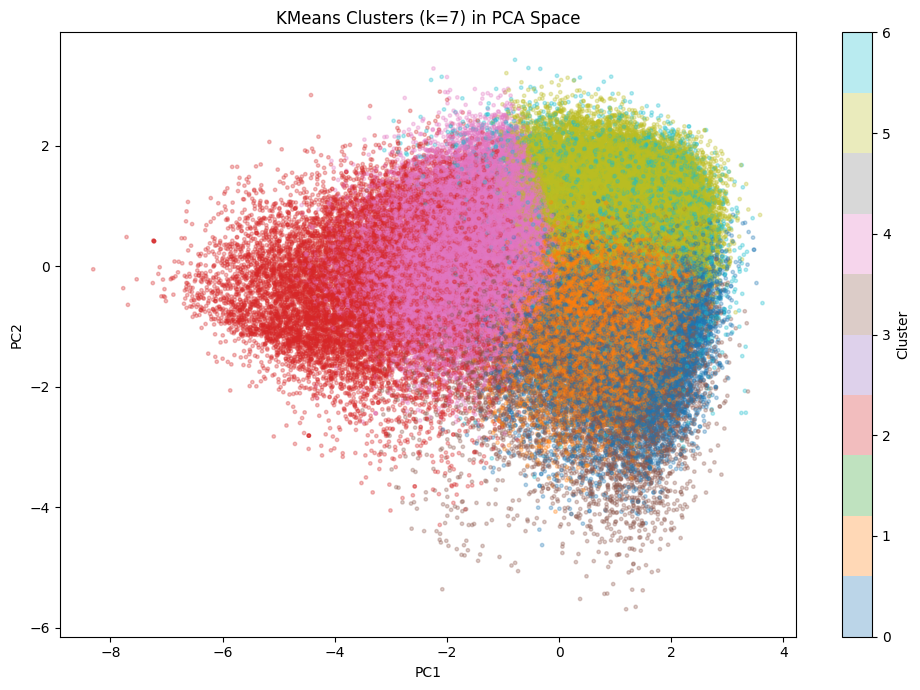

In [57]:
# Visualize clusters in PCA space
plt.figure(figsize=(10, 7))
scatter = plt.scatter(X_pca_2d[:, 0], X_pca_2d[:, 1],
                      c=cluster_labels, cmap='tab10', alpha=0.3, s=6)
plt.colorbar(scatter, label='Cluster')
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.title(f'KMeans Clusters (k={OPTIMAL_K}) in PCA Space')
plt.tight_layout()
plt.show()

**Short Answer [2 Points]:**
- What value of `k` did you choose as `OPTIMAL_K`, and why? Reference specific features of the elbow plot that guided your decision (e.g., location of the elbow, rate of inertia decrease).
- Do the cluster sizes printed above seem balanced or skewed? What might a highly skewed distribution indicate?

*I chose 7 as my value for OPTIMAL_K. This is where the inertia decrease sharply slows. It looks to me as though the slope from 6-7 clusters (and before) is a lot higher than the slope from 7-8 clusters (and after), forming a sort of elbow shape.*

*The clustered distrubution, with values at 6293 and 36392 imply that a few of the clusters are much larger than others. This indicates that there is a dense region of songs (a common style like pop, for example) and smaller, more specialized region of songs (perhaps alternative genres.)*

## 1.3 Inspect Clusters [3 Points]

Inspect cluster centroids and describe what each cluster represents musically.

In [34]:
# Compute mean of each feature per cluster
df_with_clusters = df.with_columns(pl.Series('cluster', cluster_labels.tolist()))
centroid_df = (
    df_with_clusters
    .group_by('cluster')
    .agg([pl.col(f).mean().alias(f) for f in AUDIO_FEATURES])
    .sort('cluster')
)
print(centroid_df)

shape: (7, 10)
┌─────────┬────────────┬────────────┬──────────┬───┬────────────┬───────────┬───────────┬──────────┐
│ cluster ┆ acousticne ┆ danceabili ┆ energy   ┆ … ┆ loudness   ┆ speechine ┆ tempo     ┆ valence  │
│ ---     ┆ ss         ┆ ty         ┆ ---      ┆   ┆ ---        ┆ ss        ┆ ---       ┆ ---      │
│ i64     ┆ ---        ┆ ---        ┆ f64      ┆   ┆ f64        ┆ ---       ┆ f64       ┆ f64      │
│         ┆ f64        ┆ f64        ┆          ┆   ┆            ┆ f64       ┆           ┆          │
╞═════════╪════════════╪════════════╪══════════╪═══╪════════════╪═══════════╪═══════════╪══════════╡
│ 0       ┆ 0.223508   ┆ 0.460778   ┆ 0.707283 ┆ … ┆ -7.761923  ┆ 0.074639  ┆ 165.04343 ┆ 0.616069 │
│         ┆            ┆            ┆          ┆   ┆            ┆           ┆ 5         ┆          │
│ 1       ┆ 0.112621   ┆ 0.524843   ┆ 0.723162 ┆ … ┆ -6.945629  ┆ 0.062361  ┆ 110.94780 ┆ 0.395324 │
│         ┆            ┆            ┆          ┆   ┆            ┆           

In [ ]:
centroid_df.to_pandas() # so i can view it better

,cluster,acousticness,danceability,energy,instrumentalness,liveness,loudness,speechiness,tempo,valence
0,0,0.223508,0.460778,0.707283,0.073380,0.179632,-7.761923,0.074639,165.043435,0.616069
1,1,0.112621,0.524843,0.723162,0.079330,0.175668,-6.945629,0.062361,110.947806,0.395324
2,2,0.840366,0.386578,0.211876,0.817978,0.156197,-19.275211,0.046709,106.087975,0.301041
3,3,0.351459,0.497288,0.653008,0.097331,0.724625,-9.439450,0.085071,120.694598,0.542522
4,4,0.761207,0.477163,0.264242,0.027797,0.161765,-13.897522,0.044437,109.113659,0.384849
5,5,0.318176,0.701650,0.623445,0.055612,0.151413,-8.961830,0.062163,113.500646,0.790415
6,6,0.316469,0.695467,0.580191,0.015393,0.253198,-9.751609,0.438722,115.866595,0.560343


**Short Answer [3 Points]:**
- Describe each cluster in plain English (e.g., "high energy, danceable" or "acoustic, low tempo").
- Are the clusters musically meaningful or mostly a statistical artifact?
- When would kNN be a better choice than cluster-based recommendation?

*Cluster 0: High tempo, high energy*
*Cluster 1: High enery, low acousticness and instrumentalness*
*Cluster 2 Highly accoustic, low energy, high instrumentalness, low loudness, low tempo*
*Cluster 3: High liveness*
*Cluster 4: High accousticness, low energy, low instrumentalness*
*Cluster 5: High danceability, high energy, low liveness, low speechiness*
*Cluster 6: High speechiness, high danceability*


*I believe that the clusters are musically meaningful as they each seperate a different type of music. For example, cluster 2 seems to represent calmer, more relaxed instrumental music (ex. classical music, no covals). On the other hand, cluster 6 seems to represent highly speechy and danceabile music, possibly like music from musicals. Overall, these clusters definitely provide significant seperation in the music.*

*kNNs are better for finding songs that are similar to other songs rather than just displaying groupings. kNNs could be used for finding similar songs to an inputted song, for example. Cluster-based recommendation would be useful for group-level summaries (ex. finding centroids or large playlists of similar songs)*

## 1.4 Song Recommendation [8 Points]

Implement `recommend_songs` in `transformations/transformations_stub.py` and then copy it here.

Using kNN in the audio feature space, this function finds songs whose acoustic profile
is most similar to a query song.

**Your function should:**
- Define `_AUDIO_FEATURES` inside the function (for portability)
- Extract the feature matrix from `df` using `_AUDIO_FEATURES`
- Fit `NearestNeighbors(n_neighbors=k+1)` on the feature matrix
- Find the row where `df['id'] == song_id`; return empty DataFrame if not found
- Query kNN with that song's features; exclude the query song from results
- Return a DataFrame with columns: `id`, `name`, `artists`, `popularity`

- **Standardize** the feature matrix using `StandardScaler` before fitting `NearestNeighbors`
  so that `loudness` and `tempo` do not dominate distance calculations

**Hint:** Use `nbrs.kneighbors(query_row)` to get the indices of nearest neighbors.

In [ ]:
# TODO: Copy recommend_songs from transformations/transformations_stub.py.
def recommend_songs(df: pl.DataFrame, song_id: str, k: int = 10) -> pl.DataFrame:
    """
    Recommend k similar songs using kNN on audio features.

    Requirements:
    - Use NearestNeighbors from sklearn on the AUDIO_FEATURES columns
      (defined inside this function for portability):
        ['acousticness', 'danceability', 'energy', 'instrumentalness',
         'liveness', 'loudness', 'speechiness', 'tempo', 'valence']
    - Find the row in df where column 'id' == song_id
    - Return the k nearest neighbors (excluding the query song itself)
    - Returned DataFrame must include columns: id, name, artists, popularity
    - If song_id is not found in df, return an empty DataFrame with those columns
    - Standardize the extracted feature matrix with StandardScaler before fitting
      NearestNeighbors.

    Args:
        df: Polars DataFrame with AUDIO_FEATURES columns plus id, name, artists, popularity
        song_id: The 'id' value of the query song
        k: Number of songs to recommend (default 10)

    Returns:
        Polars DataFrame with k recommended songs

    Example:
        >>> recs = recommend_songs(df, song_id='4BJqT0PrAfrxzMOxytFOIz', k=5)
        >>> recs.height
        5
        >>> '4BJqT0PrAfrxzMOxytFOIz' not in recs['id'].to_list()
        True
    """
    _AUDIO_FEATURES = [
        'acousticness', 'danceability', 'energy', 'instrumentalness',
        'liveness', 'loudness', 'speechiness', 'tempo', 'valence'
    ]
    output_columns = ["id", "name", "artists", "popularity"]

    # extensive casing where you return an empty dataframe
    query_matches = df.filter(pl.col("id") == song_id)
    if query_matches.height == 0 or df.height <= 1 or k <= 0:
        return pl.DataFrame(schema=output_columns)

    # scale features
    features = df.select(_AUDIO_FEATURES).to_numpy()
    scaled_features = StandardScaler().fit_transform(features)

    # query for the index of the song
    query_index = df.select(pl.arg_where(pl.col("id") == song_id)).item()
    neighbor_count = min(k + 1, df.height)

    # define model
    model = NearestNeighbors(n_neighbors=neighbor_count)
    model.fit(scaled_features)

    # get the indices of the neighbors
    neighbor_indices = model.kneighbors(
        scaled_features[query_index].reshape(1, -1), # reshape to fit
        return_distance=False
    )[0]

    recommended_indices = [idx for idx in neighbor_indices if idx != query_index][:k]
    return df[recommended_indices].select(output_columns)

# Example test:
recs = recommend_songs(df, df['id'][0], k=5)
assert recs.height == 5
assert df['id'][0] not in recs['id'].to_list()

In [60]:
grader.grade('test_recommend_songs', recommend_songs)

Correct! You earned 8/8 points. You are a star!

Your submission has been successfully recorded in the gradebook.


In [61]:
# Try it out — pick any song from the dataset
sample_id = df['id'][0]
sample_name = df['name'][0]
recs = recommend_songs(df, sample_id, k=5)
print(f'Recommendations for "{sample_name}":')
print(recs.select(['name', 'artists', 'popularity']))

Recommendations for "Piano Concerto No. 3 in D Minor, Op. 30: III. Finale. Alla breve":
shape: (5, 3)
┌─────────────────────────────────┬─────────────────────────────────┬────────────┐
│ name                            ┆ artists                         ┆ popularity │
│ ---                             ┆ ---                             ┆ ---        │
│ str                             ┆ str                             ┆ i64        │
╞═════════════════════════════════╪═════════════════════════════════╪════════════╡
│ Ballade No. 1 in G Minor, Op. … ┆ ['Frédéric Chopin', 'Vladimir … ┆ 11         │
│ Années de pèlerinage, Première… ┆ ['Franz Liszt', 'Vladimir Horo… ┆ 14         │
│ Ballade No. 1 in G Minor, Op. … ┆ ['Frédéric Chopin', 'Vladimir … ┆ 25         │
│ Hungarian Rhapsody No. 2 in C-… ┆ ['Franz Liszt', 'Vladimir Horo… ┆ 7          │
│ Detour Ahead - Live / Take 1    ┆ ['Bill Evans Trio']             ┆ 12         │
└─────────────────────────────────┴─────────────────────────────────

# Part 2: Decision Trees

In this section you will train and evaluate a decision tree classifier to predict
whether a song is "popular" (popularity ≥ 50).

## 2.1 Prepare Data for Classification [3 Points]

Implement `binarize_popularity` in `transformations/transformations_stub.py` and then copy it here.

**Your function should:**
- Add a `'popular'` boolean column: `True` if `popularity >= threshold`, else `False`
- Leave all other columns unchanged

**Hint:** Use `pl.col('popularity') >= threshold` as the condition.

In [11]:
def binarize_popularity(df: pl.DataFrame, threshold: int = 50) -> pl.DataFrame:
    """
    Add a 'popular' boolean column indicating whether a song is popular.

    Requirements:
    - Add a new column 'popular' (boolean):
        - True  if popularity >= threshold
        - False if popularity < threshold
    - Do not modify any existing columns

    Args:
        df: Polars DataFrame with a 'popularity' column
        threshold: Popularity cutoff (default 50)

    Returns:
        DataFrame with added 'popular' boolean column

    Example:
        >>> sample = pl.DataFrame({'popularity': [30, 50, 70]})
        >>> result = binarize_popularity(sample, threshold=50)
        >>> result['popular'].to_list()
        [False, True, True]
    """
    return df.with_columns((pl.col("popularity") >= 50).alias("popular"))

# Example test:
sample = pl.DataFrame({'popularity': [30, 50, 70]})
binarize_popularity(sample, threshold=50)['popular'].to_list()
# Expected: [False, True, True]

[False, True, True]

In [12]:
grader.grade('test_binarize_popularity', binarize_popularity)

Correct! You earned 3/3 points. You are a star!

Your submission has been successfully recorded in the gradebook.


In [65]:
# Build classification dataset and split
df_labeled = binarize_popularity(df)
y_binary = df_labeled['popular'].to_numpy().astype(int)

X_train, X_test, y_train, y_test = train_test_split(
    X, y_binary, test_size=0.2, random_state=42
)
print(f'Train: {X_train.shape}  Test: {X_test.shape}')
unique, counts = np.unique(y_train, return_counts=True)
print(f'Class distribution in train: {dict(zip(unique.tolist(), counts.tolist()))}')

Train: (110521, 9)  Test: (27631, 9)
Class distribution in train: {0: 81522, 1: 28999}


## 2.2 Train Decision Tree [3 Points]

Implement `train_decision_tree` in `transformations/transformations_stub.py` and then copy it here.

**Your function should:**
- Instantiate `DecisionTreeClassifier(max_depth=max_depth, random_state=random_state)`
- Fit it on `X_train` and `y_train`
- Return the fitted model

In [66]:
def train_decision_tree(X_train: np.ndarray, y_train: np.ndarray,
                        max_depth: int = 5, random_state: int = 42):
    """
    Train and return a DecisionTreeClassifier.

    Requirements:
    - Train a DecisionTreeClassifier with the given max_depth and random_state
    - Fit on X_train and y_train
    - Return the fitted model

    Args:
        X_train: numpy array of shape (n_train, n_features)
        y_train: numpy array of shape (n_train,) with binary labels
        max_depth: maximum tree depth (default 5)
        random_state: random seed (default 42)

    Returns:
        Fitted DecisionTreeClassifier

    Example:
        >>> model = train_decision_tree(X_train, y_train, max_depth=3)
        >>> model.tree_.max_depth <= 3
        True
    """
    model = DecisionTreeClassifier(
        max_depth=max_depth,
        random_state=random_state,
    )
    model.fit(X_train, y_train)
    return model

In [67]:
grader.grade('test_train_decision_tree', train_decision_tree)

Correct! You earned 3/3 points. You are a star!

Your submission has been successfully recorded in the gradebook.


In [68]:
# Train at several depths to observe the effect
dt_model = train_decision_tree(X_train, y_train, max_depth=5)
print(f'Tree depth: {dt_model.tree_.max_depth}')
print(f'Number of leaves: {dt_model.tree_.n_leaves}')

Tree depth: 5
Number of leaves: 32


## 2.3 Evaluate Classifier [8 Points]

Implement `evaluate_classifier` in `transformations/transformations_stub.py` and then copy it here.

**Your function should:**
- Call `model.predict(X_test)` to get predictions
- Compute `accuracy_score` and `f1_score(average='weighted')`
  (`'weighted'` averages per-class F1 scores weighted by support, handling class imbalance
  better than `'macro'` when one class (e.g. unpopular songs) vastly outnumbers the other)
- Return `{'accuracy': float, 'f1': float}`

In [71]:
def evaluate_classifier(model, X_test: np.ndarray, y_test: np.ndarray) -> dict:
    """
    Evaluate a classifier and return performance metrics.

    Requirements:
    - Generate predictions using model.predict(X_test)
    - Compute accuracy and weighted F1 score
    - Return a dict with keys 'accuracy' and 'f1'
    - Both values should be floats between 0.0 and 1.0

    Args:
        model: Fitted classifier with a predict method
        X_test: numpy array of test features
        y_test: numpy array of true labels

    Returns:
        Dict with keys: 'accuracy' (float), 'f1' (float)

    Example:
        >>> metrics = evaluate_classifier(model, X_test, y_test)
        >>> 0.0 <= metrics['accuracy'] <= 1.0
        True
    """
    y_pred = model.predict(X_test)

    accuracy = float(np.mean(y_pred == y_test))

    labels = np.unique(y_test) # in weighted F1 weights come from all labels
    total = len(y_test)
    weighted_f1 = 0.0

    for label in labels:
        # calculate components
        true_positive = np.sum((y_pred == label) & (y_test == label))
        false_positive = np.sum((y_pred == label) & (y_test != label))
        false_negative = np.sum((y_pred != label) & (y_test == label))

        precision_denominator = true_positive + false_positive
        recall_denominator = true_positive + false_negative

        precision = (
            true_positive / precision_denominator
            if precision_denominator > 0 else 0.0
        )
        recall = (
            true_positive / recall_denominator
            if recall_denominator > 0 else 0.0
        )

        f1 = (
            2 * precision * recall / (precision + recall)
            if (precision + recall) > 0 else 0.0
        )
        support = np.sum(y_test == label)
        weighted_f1 += (support / total) * f1 # add into weighted_f1

    return {
        'accuracy': accuracy,
        'f1': float(weighted_f1),
    }

In [72]:
grader.grade('test_evaluate_classifier', evaluate_classifier)

Correct! You earned 6/6 points. You are a star!

Your submission has been successfully recorded in the gradebook.


In [73]:
# Evaluate and compare depths
for depth in [3, 5, 10, None]:
    m = train_decision_tree(X_train, y_train, max_depth=depth)
    metrics = evaluate_classifier(m, X_test, y_test)
    label = str(depth) if depth else 'unlimited'
    print(f'  max_depth={label:>9}  accuracy={metrics["accuracy"]:.3f}  f1={metrics["f1"]:.3f}')

  max_depth=        3  accuracy=0.753  f1=0.735
  max_depth=        5  accuracy=0.770  f1=0.746
  max_depth=       10  accuracy=0.776  f1=0.761
  max_depth=unlimited  accuracy=0.697  f1=0.698


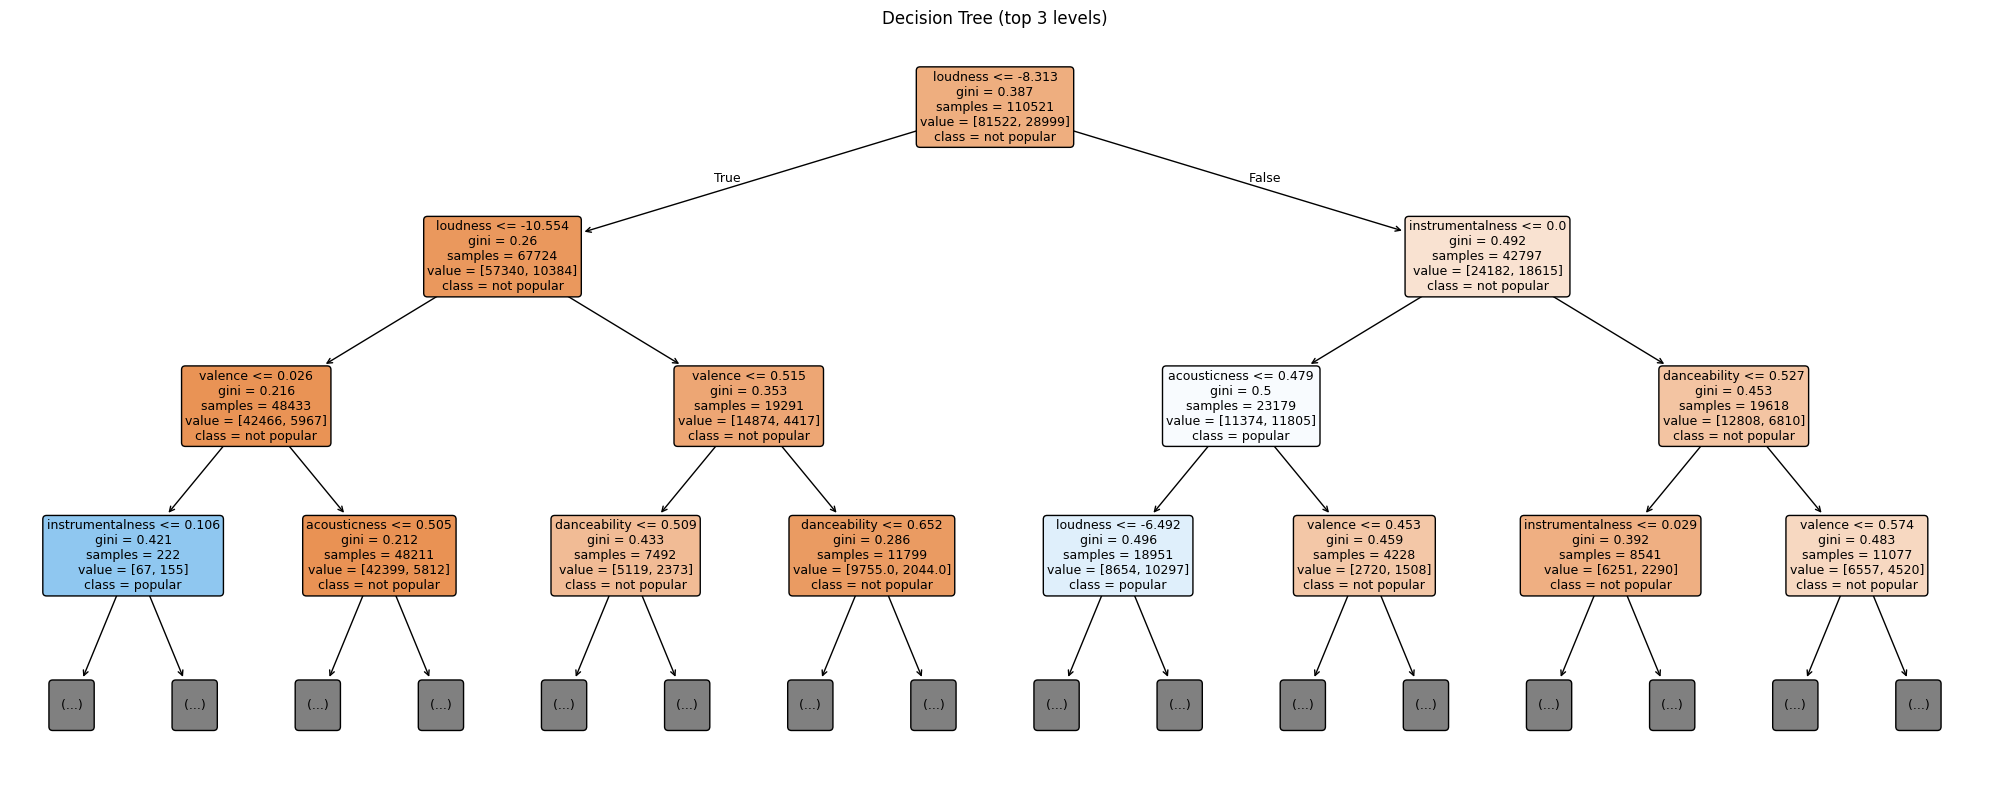

In [74]:
# Visualize the top 3 levels of the decision tree
from sklearn.tree import plot_tree

plt.figure(figsize=(20, 8))
plot_tree(dt_model, feature_names=AUDIO_FEATURES,
          class_names=['not popular', 'popular'],
          max_depth=3, filled=True, rounded=True, fontsize=9)
plt.title('Decision Tree (top 3 levels)')
plt.tight_layout()
plt.show()

**Short Answer [2 Points]:**
- Which features appear at the top splits of the tree? Does this make musical sense?
- What happens to accuracy as `max_depth` increases? What does this tell you about overfitting?

*Loudness and instrumentalness appear at the top splits of the tree. Recall that the top splits of the tree are the main categorizers of data into homogeneous categories. This makes sense for loudness as music can generally be split into categories based on their loudness. Genres like pop, hip-hop, and EDM have their loudness purposely turned up in order to sound more intense. On the other hand, genres like classical are not composed for loudness and can have varying degrees of dynamics. Then, it makes sense that loudness can categorize music into distinct sections. Instrumentalness also makes sense for the same reason. Different genres of music are defined by how many instruments they use (ex. a capella vs orchestra). Thus, using instrumentalness as a can easily split the genres into different types of music.*

*As max_depth increases accuracy increases and then decreases. This means that the tree is overfitting to noise and not capturing data pattern that are helpful for the model classification.*

# Part 3: Linear Models

In this section you will use linear regression to predict a song's raw popularity score
and compare it with the decision tree.

## 3.1 Train and Evaluate Linear Regression [6 Points]

Implement `train_and_evaluate_linear_regression` in `transformations/transformations_stub.py` and then copy it here.

**Important:** In this homework, you will be **given** training data (`X` and `y`) from the cleaned Spotify dataset. You should treat these as the full training set (no additional train/validation
split inside this function).

**Your function should:**
- Accept feature matrix `X` (numpy array) and target vector `y` (numpy array of popularity scores)
- Standardize features using `StandardScaler` (fit on X, transform X)
- Fit a `LinearRegression` model on the standardized training data
- Return a dict with a single key `'model'`, where the value is a fitted sklearn `Pipeline`
  that contains a `StandardScaler` step followed by a `LinearRegression` step

In [75]:
def train_and_evaluate_linear_regression(
    X: np.ndarray,
    y: np.ndarray,
    random_state: int = 42,
) -> dict:
    """
    Train a standardized linear regression model to predict song popularity.

    Requirements:
    - Treat X and y as the **full training dataset** (no internal train/validation split).
    - Standardize features using StandardScaler (fit on X, transform X).
    - Fit a LinearRegression model on the standardized training data.
    - Return a dict with a single key:
        - 'model': a fitted sklearn Pipeline that contains a StandardScaler
          step followed by a LinearRegression step. This allows the model to
          be evaluated on unseen data (held-out validation / test sets) using
          raw (unscaled) feature matrices.

    Args:
        X: numpy array of shape (n_samples, n_features) with audio features
        y: numpy array of shape (n_samples,) with popularity scores
        random_state: random seed you may use if needed (e.g., for reproducibility
                      in any randomized steps; not strictly required)

    Returns:
        Dict with a single key 'model' mapping to the fitted Pipeline.

    Example:
        >>> X = np.random.random((200, 9))
        >>> y = X.sum(axis=1) * 10  # synthetic linear target
        >>> result = train_and_evaluate_linear_regression(X, y, random_state=0)
        >>> isinstance(result['model'], sklearn.pipeline.Pipeline)
        True
    """
    model = Pipeline([
        ('scaler', StandardScaler()),
        ('linear_regression', LinearRegression()),
    ])
    model.fit(X, y)
    return {'model': model}

# Example test (using the AUDIO_FEATURES matrix X and popularity from df):
y_reg = df['popularity'].to_numpy().astype(float)
result = train_and_evaluate_linear_regression(X, y_reg, random_state=42)
model = result['model']

In [76]:
# Before grading, you can use this cell to evaluate your model's performance on the dataset.

from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score

# Using the AUDIO_FEATURES matrix X and the true popularity scores
y_reg = df['popularity'].to_numpy().astype(float)

X_train_lr, X_val_lr, y_train_lr, y_val_lr = train_test_split(
    X, y_reg, test_size=0.2, random_state=42
)

linreg_result = train_and_evaluate_linear_regression(X_train_lr, y_train_lr, random_state=42)
model = linreg_result['model']

y_val_pred = model.predict(X_val_lr)
rmse_val = np.sqrt(mean_squared_error(y_val_lr, y_val_pred))
r2_val = r2_score(y_val_lr, y_val_pred)

print(f"Linear regression RMSE on held-out validation split: {rmse_val:.3f}")
print(f"Linear regression R^2 on held-out validation split: {r2_val:.3f}")

Linear regression RMSE on held-out validation split: 14.776
Linear regression R^2 on held-out validation split: 0.285


In [77]:
# Show 10 random songs with true vs predicted popularity (using validation model)
import numpy as np

# Convert to pandas for easy row sampling and display
df_pd = df.to_pandas()

np.random.seed(0)
indices = np.random.choice(len(df_pd), size=10, replace=False)

sample = df_pd.loc[indices, ['name', 'artists', 'popularity']].copy()
sample['predicted_popularity'] = model.predict(X[indices])

sample

,name,artists,popularity,predicted_popularity
34398,Keep It To Yourself,['Sonny Boy Williamson II'],21,28.698970
95401,You Were the Fool,['Ween'],36,34.207202
87784,La scala di seta: Overture - Remastered,"['Gioachino Rossini', 'Fritz Reiner', 'Chicago...",14,28.712621
7686,Forever - Remastered 2009,['The Beach Boys'],50,38.548428
131688,Languis - Remasterizado 2007,['Soda Stereo'],45,44.382922
120227,"Run, Baby, Run",['Sheryl Crow'],43,47.563700
24521,Get It Up,['The Time'],43,42.214630
20507,Bye Bye Love,['Roy Orbison'],37,29.793454
127222,For a Few Dollars More: Mortimer & The Chest,['Ennio Morricone'],18,31.581560
71250,Meet Me on the Equinox,['Death Cab for Cutie'],48,45.658287


In [78]:
grader.grade('test_train_and_evaluate_linear_regression', train_and_evaluate_linear_regression)

Correct! You earned 6/6 points. You are a star!

Your submission has been successfully recorded in the gradebook.


# Final Reflection [3 Points]

Answer all three questions below in the cell that follows.

1. **Interpretability:** Which model was most interpretable, and why?
2. **Performance:** Which model performed best on its respective task? What metric did you use?
3. **Improvement:** What is one thing you would try if you had more data, time, or features?

*Your answers here:*

1. The decision tree model was the most interpretable. Using the visualization, you could really easily figure out exactly how the tree made the decision and which conditions it used. 

2. From a high level, I believe that the Decision Tree Classifier performed the best on it's task. It achieved an accuracy of around 0.776 and an F1 score of 0.761. For the binary popularity classification task it performed, I believe that it balanced true positives and negatives reasonably well. 

Next, the linear regression RMSE was 14.776 and the R^2 value was 0.285. While the lienar model does capture about 28.5% of the variance, it still has substantial error. This could be because linear models capture broad trends but may struggle with noisy targets like song popularity. 

Finally, I think that the KMeans/PCA/Nearest Neighbors model from Part 1 worked reasonably well. THe test examples I did gave me similar songs to the ones inputted. However, for song recommendation, it's possible that the model produced *similar* songs rather than songs that the user would actually enjoy. THe quality of the model would depend on the features and whether the feature-sapce actually matches human notions of recommendation. This is why I believe that the strategy of KMeans/PCA is useful for exploratory visualization, but it might be harder to evaluate the true usefulness of the model.

3. I would try using an ensemble training method--combining lots of models together that do the same thing. For example, I could modify the decision tree model to be a random forest instead. A random forest could have less variance than the original model. 

## Submission

When you are done:
1. Implement all functions in `transformations/transformations_stub.py`
2. Copy each implementation into the corresponding notebook cell
3. Run all cells top-to-bottom to verify correctness
4. Upload to Gradescope:
   - `homework-3-notebook.ipynb`
   - `transformations/transformations_stub.py`